In [ ]:
import sklearn as sk
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_final=pd.read_csv("Algerian Fire Clean.csv")

In [3]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    float64
 1   month        243 non-null    float64
 2   year         243 non-null    float64
 3   Temperature  243 non-null    float64
 4   RH           243 non-null    float64
 5   Ws           243 non-null    float64
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    str    
 14  Region       243 non-null    float64
dtypes: float64(14), str(1)
memory usage: 28.6 KB


In [4]:
df_final.drop(["day","month","year"],axis=1,inplace=True)

In [5]:
df_final["Classes"]=np.where(df_final["Classes"].str.contains("not fire"),0,1)

In [6]:
df_final["Classes"].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [7]:
X=df_final.drop('FWI',axis=1)
Y=df_final[['FWI']]

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.30,random_state=42)

In [10]:
from sklearn.linear_model import LinearRegression as LR

<Axes: >

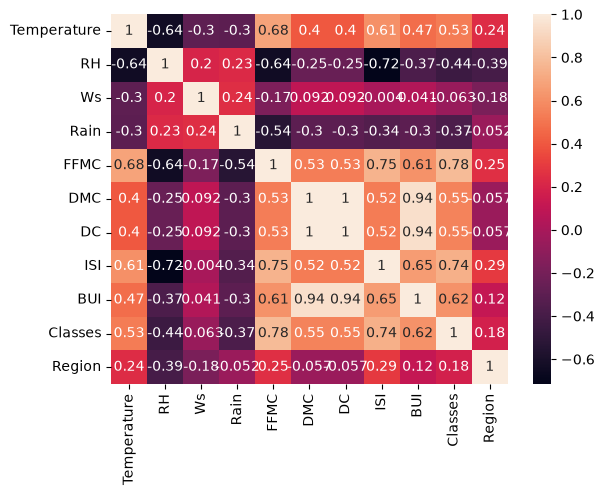

In [11]:
corr=X_train.corr()
sns.heatmap(corr,annot=True)

In [12]:
def corrrrr(dataset,threshold):
    col_corr=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]>threshold):
                colname=corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [13]:
dropfeature=corrrrr(X_train,0.85)

In [14]:
X_train.drop(dropfeature,axis=1,inplace=True)
X_test.drop(dropfeature,axis=1,inplace=True)

In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
Scale=StandardScaler()

In [17]:
X_train=Scale.fit_transform(X_train)
X_test=Scale.transform(X_test)

In [18]:
Regression=LR()

In [19]:
Regression.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
y_pred=Regression.predict(X_test)

In [21]:
mae=mean_absolute_error(Y_test,y_pred)
mse=mean_squared_error(Y_test,y_pred)
score=r2_score(Y_test,y_pred)
print(mae)
print(mse)
print(score)

0.736214966583964
1.2544223418041751
0.9719346170761843


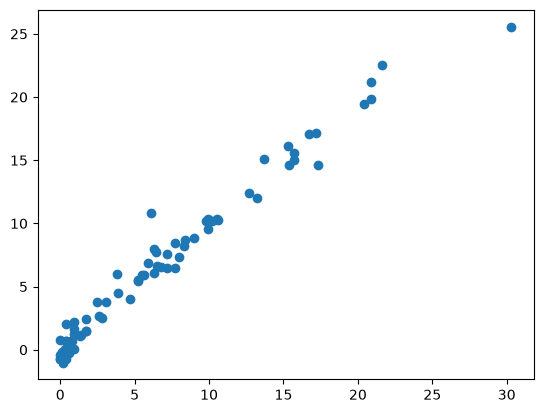

In [22]:
plt.scatter(Y_test,y_pred)

LassoRegression

In [23]:
from sklearn.linear_model import Lasso

In [24]:
Lassopred=Lasso()

In [25]:
Lassopred.fit(X_train,Y_train)
y_pred_l=Lassopred.predict(X_test)


In [26]:
Lmae=mean_absolute_error(Y_test,y_pred_l)
Lmse=mean_squared_error(Y_test,y_pred_l)
Lscore=r2_score(Y_test,y_pred_l)
print(Lmae)
print(Lmse)
print(Lscore)

1.1046040775557706
2.6250898746980664
0.9412684627117924


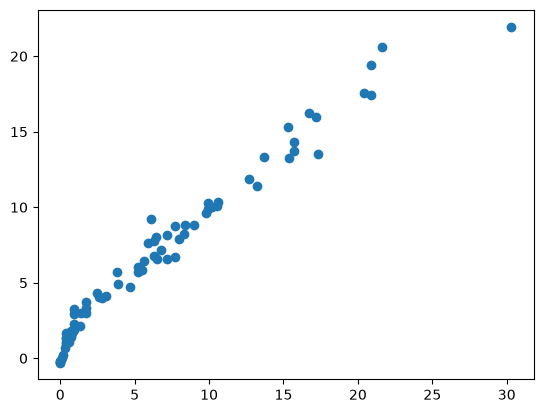

In [27]:
plt.scatter(Y_test,y_pred_l)

Ridge

In [28]:
from sklearn.linear_model import Ridge

In [29]:
Ridgepred=Ridge()

In [30]:
Ridgepred.fit(X_train,Y_train)
y_pred_R=Ridgepred.predict(X_test)


In [31]:
Rmae=mean_absolute_error(Y_test,y_pred_R)
Rmse=mean_squared_error(Y_test,y_pred_R)
Rscore=r2_score(Y_test,y_pred_R)
print(Rmae)
print(Rmse)
print(Rscore)

0.7367328231413461
1.2771621352889309
0.9714258561983764


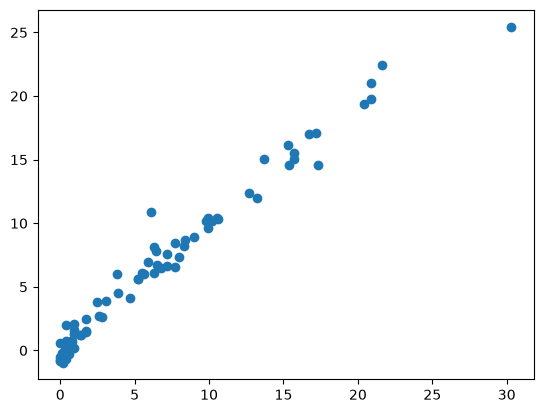

In [32]:
plt.scatter(Y_test,y_pred_R)

ElasticNet

In [33]:
from sklearn.linear_model import ElasticNet

In [34]:
ElasticNet=ElasticNet()

In [35]:
ElasticNet.fit(X_train,Y_train)
y_pred_E=ElasticNet.predict(X_test)


In [36]:
Emae=mean_absolute_error(Y_test,y_pred_E)
Emse=mean_squared_error(Y_test,y_pred_E)
Escore=r2_score(Y_test,y_pred_E)
print(Emae)
print(Emse)
print(Escore)

1.9964260558156188
6.376027109636394
0.8573481702285322


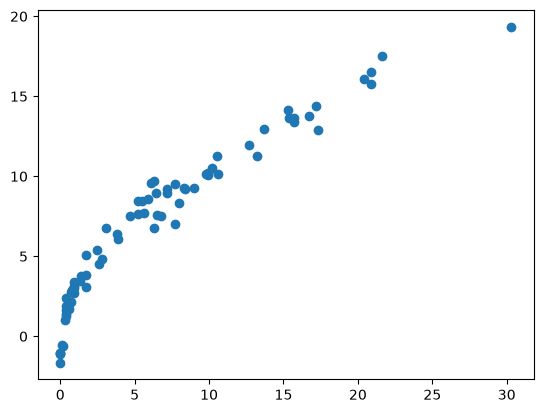

In [37]:
plt.scatter(Y_test,y_pred_E)

Hyperparameter Tuning

LASSOCV

In [38]:
from sklearn.linear_model import LassoCV

In [39]:
CV=LassoCV(cv=5)

In [40]:
CV.fit(X_train,Y_train)

c:\Users\Aryan Chauhan\anaconda3\envs\sklearn-env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [41]:
CV_pred=CV.predict(X_test)

In [42]:
CV.alpha_

np.float64(0.06177603120682054)

In [43]:
CV.alphas_

array([7.1027424 , 6.62404134, 6.17760312, 5.76125335, 5.37296415,
       5.01084435, 4.67313021, 4.35817688, 4.06445034, 3.79051999,
       3.53505163, 3.29680098, 3.07460763, 2.86738937, 2.67413692,
       2.49390904, 2.32582792, 2.1690749 , 2.02288651, 1.88655073,
       1.75940353, 1.64082562, 1.53023946, 1.42710644, 1.33092425,
       1.24122441, 1.15757004, 1.07955369, 1.00679538, 0.93894074,
       0.87565928, 0.81664278, 0.76160379, 0.71027424, 0.66240413,
       0.61776031, 0.57612533, 0.53729642, 0.50108444, 0.46731302,
       0.43581769, 0.40644503, 0.379052  , 0.35350516, 0.3296801 ,
       0.30746076, 0.28673894, 0.26741369, 0.2493909 , 0.23258279,
       0.21690749, 0.20228865, 0.18865507, 0.17594035, 0.16408256,
       0.15302395, 0.14271064, 0.13309242, 0.12412244, 0.115757  ,
       0.10795537, 0.10067954, 0.09389407, 0.08756593, 0.08166428,
       0.07616038, 0.07102742, 0.06624041, 0.06177603, 0.05761253,
       0.05372964, 0.05010844, 0.0467313 , 0.04358177, 0.04064

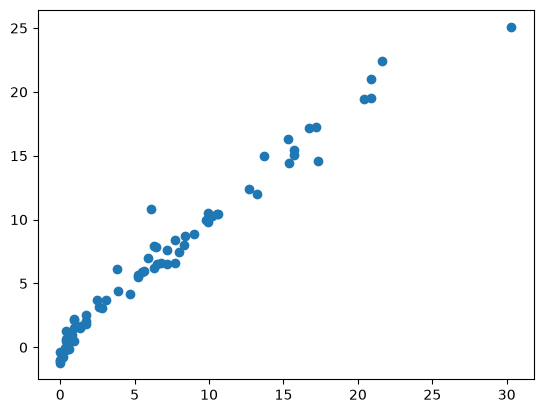

In [44]:
plt.scatter(Y_test,CV_pred)

In [45]:
CVmae=mean_absolute_error(Y_test,CV_pred)
CVmse=mean_squared_error(Y_test,CV_pred)
CVscore=r2_score(Y_test,CV_pred)
print(CVmae)
print(CVmse)
print(CVscore)

0.7410118676965242
1.3172538619838055
0.9705288778647871


RIDGECV

In [46]:
from sklearn.linear_model import RidgeCV

In [47]:
CVR=RidgeCV(cv=5)

In [48]:
CVR.fit(X_train,Y_train)

,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.","(0.1, ...)"
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error ` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`coefficient of determination ` (:math:`R^2`) otherwise.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-One-Out cross-validation- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used, else,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",5
,"gcv_mode gcv_mode: {'auto', 'svd', 'eigen'}, default='auto'Flag indicating which strategy to use when performingLeave-One-Out Cross-Validation. Options are:: 'auto' : use 'svd' if n_samples > n_features, otherwise use 'eigen' 'svd' : force use of singular value decomposition of X when X is dense, eigenvalue decomposition of X^T.X when X is sparse. 'eigen' : force computation via eigendecomposition of X.X^TThe 'auto' mode is the default and is intended to pick the cheaperoption of the two depending on the shape of the training data.",None
,"store_cv_results store_cv_results: bool, default=FalseFlag indicating if the cross-validation values corresponding toeach alpha should be stored in the ``cv_results_`` attribute (seebelow). This flag is only compatible with ``cv=None`` (i.e. usingLeave-One-Out Cross-Validation)... versionchanged:: 1.5 Parameter name changed from `store_cv_values` to `store_cv_results`.",False
,"alpha_per_target alpha_per_target: bool, default=FalseFlag indicating whether to optimize the alpha value (picked from the`alphas` parameter list) for each target separately (for multi-outputsettings: multiple prediction targets). When set to `True`, afterfitting, the `alpha_` attribute will contain a value for each target.When set to `False`, a single alpha is used for all targets... versionadded:: 0.24",False


In [49]:
CV_pred_R=CVR.predict(X_test)

In [50]:
CVR.alpha_

np.float64(10.0)

In [51]:
CVR.alphas

(0.1, 1.0, 10.0)

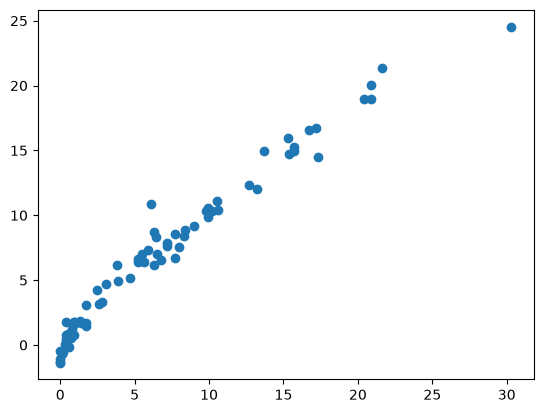

In [52]:
plt.scatter(Y_test,CV_pred_R)

In [53]:
CVRmae=mean_absolute_error(Y_test,CV_pred_R)
CVRmse=mean_squared_error(Y_test,CV_pred_R)
CVRscore=r2_score(Y_test,CV_pred_R)
print(CVRmae)
print(CVRmse)
print(CVRscore)

0.8979321835161216
1.7096817435223592
0.9617490288471741
